# 19: Can the Crystal Tell Two Pasts Apart?

Both experiments are included. V1 is statistically detectable but fails the predeclared magnitude gate. V2 removes the symbolic decoder and also formally fails.


In [1]:
from pathlib import Path
import json
import math
import random
import sys
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams, CrystalState, neighbors, hex_distance, hex_capacity,
    axial_to_xy, logistic, local_exposure_angle, initial_state, clone_state,
    morphology_hash, frontier, attachment_probability, advance_one_step,
    run_crystal, cell_keyed_uniform,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

NOTEBOOK_PROFILE = "quick"
RUN_CANONICAL = False

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def audit(expected, observed, source):
    return {
        "source": source,
        "expected": expected,
        "observed": observed,
        "matches": {k: observed.get(k) == v for k, v in expected.items()},
    }

def plot_cells(cells, title, ax=None, color="tab:blue"):
    ax = ax or plt.gca()
    pts = np.array([axial_to_xy(c) for c in cells]) if cells else np.empty((0, 2))
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], marker="h", s=42, c=color, alpha=0.9)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


In [2]:
EXPERIMENT = {"v1": "symbolic HISTORY_A/HISTORY_B", "v2": "same MODIFIED material in different directional regions", "do_not_try_new_probes": True}
EXPERIMENT


{'v1': 'symbolic HISTORY_A/HISTORY_B',
 'v2': 'same MODIFIED material in different directional regions',
 'do_not_try_new_probes': True}

## p < 0.05 is not enough


In [3]:
effect = 0.00440
seed_noise_sd = 0.011489778050706978
effect_sd = effect / seed_noise_sd
{"p_value_can_pass": True, "effect_fraction_of_population": effect, "effect_in_seed_noise_sd": effect_sd, "required_sd": 0.5, "magnitude_gate_passed": effect_sd >= 0.5}


{'p_value_can_pass': True,
 'effect_fraction_of_population': 0.0044,
 'effect_in_seed_noise_sd': 0.3829490857509875,
 'required_sd': 0.5,
 'magnitude_gate_passed': False}

## Canonical artifact audit: V1 and V2


In [4]:
v1 = load_json("research/digital-life/ch19-two-pasts-v1/stage-04-verdict.json")
v2_diag = load_json("research/digital-life/ch19-two-pasts-v2/stage-02-mechanism-audit.json")
v2_primary = load_json("research/digital-life/ch19-two-pasts-v2/stage-03-primary.json")
v2 = load_json("research/digital-life/ch19-two-pasts-v2/stage-04-verdict.json")
observed = {
    "v1_status": v1["status"],
    "v1_interaction": round(v1["primary_mean_normalized_interaction"], 5),
    "v1_p": round(v1["primary_p_value"], 5),
    "v1_effect_sd": round(v1["effect_in_seed_noise_sd"], 3),
    "v2_initial_writes": round(v2_diag["mean_initial_write_count"], 1),
    "v2_cumulative_A": v2_diag["mean_cumulative_propagation_A"],
    "v2_cumulative_B": v2_diag["mean_cumulative_propagation_B"],
    "v2_primary_effect": round(v2["primary_mean_material_mediated_interaction"], 6),
    "v2_p": round(v2["primary_p_value"], 3),
    "v2_effect_sd": round(v2["effect_in_seed_noise_sd"], 3),
    "v2_status": v2["status"],
}
EXPECTED = {"v1_status": "FAILED", "v1_interaction": 0.00440, "v1_p": 0.00025, "v1_effect_sd": 0.383, "v2_initial_writes": 19.6, "v2_cumulative_A": 78.5, "v2_cumulative_B": 78.5, "v2_primary_effect": 0.000431, "v2_p": 0.163, "v2_effect_sd": 0.033, "v2_status": "FAILED"}
audit(EXPECTED, observed, "canonical report artifact")


{'source': 'canonical report artifact',
 'expected': {'v1_status': 'FAILED',
  'v1_interaction': 0.0044,
  'v1_p': 0.00025,
  'v1_effect_sd': 0.383,
  'v2_initial_writes': 19.6,
  'v2_cumulative_A': 78.5,
  'v2_cumulative_B': 78.5,
  'v2_primary_effect': 0.000431,
  'v2_p': 0.163,
  'v2_effect_sd': 0.033,
  'v2_status': 'FAILED'},
 'observed': {'v1_status': 'FAILED',
  'v1_interaction': 0.0044,
  'v1_p': 0.00025,
  'v1_effect_sd': 0.383,
  'v2_initial_writes': 19.6,
  'v2_cumulative_A': 78.5,
  'v2_cumulative_B': 78.5,
  'v2_primary_effect': 0.000431,
  'v2_p': 0.163,
  'v2_effect_sd': 0.033,
  'v2_status': 'FAILED'},
 'matches': {'v1_status': True,
  'v1_interaction': True,
  'v1_p': True,
  'v1_effect_sd': True,
  'v2_initial_writes': True,
  'v2_cumulative_A': True,
  'v2_cumulative_B': True,
  'v2_primary_effect': True,
  'v2_p': True,
  'v2_effect_sd': True,
  'v2_status': True}}

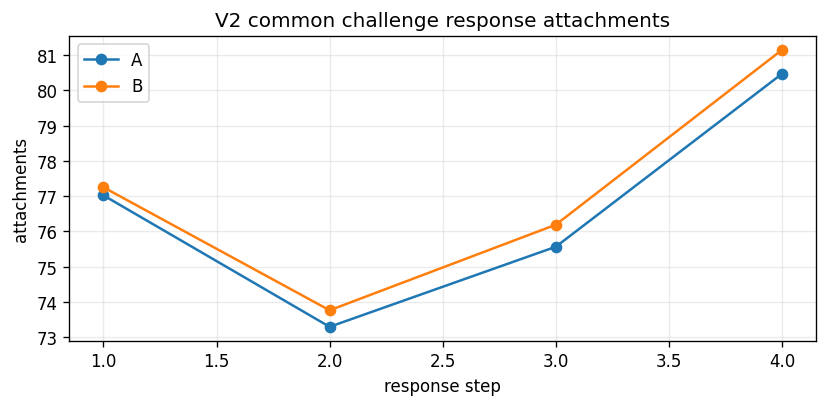

{'A': [77.02083333333333, 73.29166666666667, 75.5625, 80.46875],
 'B': [77.25, 73.76041666666667, 76.1875, 81.14583333333333],
 'retained': -0.0003542455497144991,
 'erased': -0.0007855256382132327}

In [5]:
steps = [1, 2, 3, 4]
A = v2_primary["mean_challenge_attachments_by_response_step"]["A"]
B = v2_primary["mean_challenge_attachments_by_response_step"]["B"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(steps, A, marker="o", label="A")
ax.plot(steps, B, marker="o", label="B")
ax.set(title="V2 common challenge response attachments", xlabel="response step", ylabel="attachments")
ax.legend(); ax.grid(alpha=0.25); fig.tight_layout()
fig.savefig(FIG_DIR / "ch19-v2-common-challenge-audit.png", bbox_inches="tight")
plt.show()
{"A": A, "B": B, "retained": v2_primary["retained_history_interaction"]["mean"], "erased": v2_primary["erased_geometry_only_interaction"]["mean"]}


## Bounded conclusion

Persistent trace != accessible trace != distinguishable trace != readable trace. V1 failed because the effect was below the predeclared scientific magnitude gate despite statistical significance. V2 failed after removing the symbolic decoder: histories remained different and accessible, but the later common probe did not produce a meaningful history-dependent response.

## Provenance

Book chapter: `content/books/digital-life/19-two-pasts/index.md`

Research scripts: `ch19_digital_crystal_two_pasts_v1.py`, `ch19_digital_crystal_two_pasts_v2.py`

Canonical artifacts: `research/digital-life/ch19-two-pasts-v1/`, `research/digital-life/ch19-two-pasts-v2/`

Execution mode: quick demonstration + canonical-artifact-audit
